# GIA - APRNS

## Sesión: Modelos Autoregresivos

Esta sesión de laboratorio vamos a probar los diferentes modelos autoregresivos que hemos visto en teoría.

Como recordaréis este tipo de modelos estiman una distribución de probabilidad asumiendo que podemos reescribirla mediante la regla del producto:

$p(x_1,...,x_n) = \prod^n_{i=1} p(x_i| x_{<i}) $

La arquitectura de la red reproduce esta estructura autoregresiva de manera que para obtener muestras/probabilidades debemos iterativamente calcular la distribución de cada variable.


Para los ejemplos de modelos autoregresivos usaremos la libreria `pytorch_generative`. Antes de ejecutar el notebook deberemos instalarla descomentando la siguiente celda. Una vez instalada deberemos **reiniciar** el notebook para que este disponible (en colab no debería hacer falta)

In [1]:
!git clone https://www.github.com/EugenHotaj/pytorch-generative
!pip install -r pytorch-generative/requirements.txt


Cloning into 'pytorch-generative'...
remote: Enumerating objects: 1548, done.
remote: Counting objects: 100% (426/426), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 1548 (delta 324), reused 389 (delta 298), pack-reused 1122 (from 1)
Receiving objects: 100% (1548/1548), 48.31 MiB | 16.42 MiB/s, done.
Resolving deltas: 100% (1058/1058), done.


In [2]:
!mv /content/pytorch-generative/pytorch_generative/ /content/pytorch_generative/

In [3]:
import sys
sys.path.insert(1, "/content/pytorch_generative/")
print(sys.path)

['/content', '/content/pytorch_generative/', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython']


In [4]:
from torch import optim
from torch.optim import lr_scheduler
from torch.nn import functional as F
import numpy as np
from pytorch_generative import datasets, models
from tqdm import  tqdm
import torch

from time import time
from datetime import timedelta
init_time = time()

device = torch.device("cuda")

torch.__version__, torch.cuda.is_available(), device

/content/pytorch_generative/models/autoregressive/made.py:8: SyntaxWarning: invalid escape sequence '\p'
  specifically modelling P(X) = \prod_i^D p(X_i|X_{j<i}) where X is an input
/content/pytorch_generative/models/autoregressive/nade.py:6: SyntaxWarning: invalid escape sequence '\p'
  P(X) = \prod_i^D p(X_i|X_{j<i}), where X is a feature vector and D is the
/content/pytorch_generative/models/kde.py:5: SyntaxWarning: invalid escape sequence '\s'
  p(x) is estimated as p(x) = 1 / |D| \sum_{x_i \in D} K(u(x, x_i)), where u is some


('2.9.0+cu126', True, device(type='cuda'))

In [5]:
!nvidia-smi

Mon Dec  1 16:15:01 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             10W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Funciones auxiliares

Esta función realiza el entrenamiento de un modelo y retorna el valor de la función de pérdida de todo el entrenamiento.


Solo utiliza una muestra de entrenamiento, si queréis que se use una muestra de test para  monitorizar la sobre especialización o usarla para terminar el entrenamiento deberéis modificar la función vosotros.


In [6]:
# Training loop para los diferentes modelos
def train_loop(model, optimizer, scheduler, loss_fn, dataloader, epochs):
    hist_loss = []
    pbar = tqdm(range(epochs))
    for epoch in pbar:  # bucle para todos los epochs
        running_loss = 0.0
        for i, data in enumerate(dataloader):
            # obtenemos los datos y los subimos a la GPU
            inputs = data.to(device)

            # Reiniciamos los gradientes
            optimizer.zero_grad()

            # Aplicamos los datos al modelo
            outputs = model(inputs)

            # Calculamos la perdida
            loss = loss_fn(inputs, outputs)

            # Hacemos el paso hacia atras
            loss.backward()
            optimizer.step()

            # Vamos guardando la perdida
            running_loss += loss.item()

        if scheduler is not None:
            scheduler.step()
            lr = f'lr: {scheduler.get_last_lr()[0]:.4E}'
        else:
            lr = ''

        hist_loss.append(running_loss / i)
        pbar.set_description(f'loss: {running_loss / i:3.4f}:{lr}')

    return hist_loss

In [7]:
# Cambiar para reducir o aumentar el tiempo de entrenamiento
epochs1 = 5000
epochs2 = 2000

# MADE (Masked Autoencoder for Density Estimation)

El primer modelo que veremos es MADE.

Este es un auto codificador que utiliza enmascaramiento (masking) para definir una red que representa una distribucion de probabilidad de manera autoregresiva. Podéis repasar los detalles del modelo en las transparencias de teoría.

Usaremos el dataset digits de `scikit-learn` seleccionando una de las clases para que no se alargue mucho el entrenamiento y binarizando su valores de manera que tengamos una distribucion binomial/Bernoulli para cada uno de los píxeles

In [8]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import Binarizer
import matplotlib.pyplot as plt
from torch.utils.data import Dataset

Seleccionaremos el 0, pero podéis cambiarlo al dígito que queráis

In [9]:
Xo,y =  load_digits(n_class=10, return_X_y=True)
X = Xo[y==0]
Xb = Binarizer(threshold=7).fit_transform(X)

Podemos ver los ejemplos antes y despues de la binarización. Cambiando el valor límite al binarizar cambiaremos la distribución. En este caso hemos puesto el límite en el valor de pixel 7.

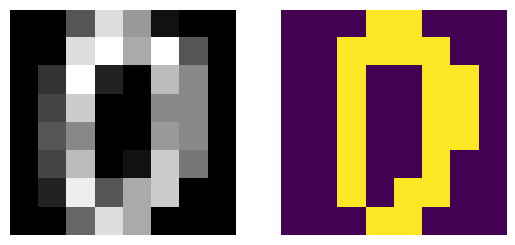

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.matshow(X[0].reshape(8,8),cmap='gray')
ax1.axis('off')
ax2.matshow(Xb[0].reshape(8,8))
ax2.axis('off')
0;

Necesitaremos un dataloader para hacer el bucle de entrenamiento del modelo. En este caso convertiremos los datos a tensores y los redimensionaremos para que sean una matriz cuadrada (8x8) en lugar de un vector como están originalmente.

In [11]:
# Dataset para los digitos binarizados
class BinDigits(Dataset):
    def __init__(self, data):
        self.data = torch.reshape(torch.Tensor(data), (-1,8,8)).unsqueeze(1)

    def __getitem__(self, index):
        x = self.data[index]

        return x

    def __len__(self):
        return len(self.data)

digdata = BinDigits(Xb)
bindig_dl = torch.utils.data.DataLoader(digdata, batch_size=32)

Definimos como función de perdida la entropia cruzada binaria. En este caso estamos aprendiendo una distribución binomial para las variables y queremos que se acerquen a los valores binarios de los píxeles.

In [12]:
def loss_fn(x, preds):
    batch_size = x.shape[0]
    x, preds = x.view((batch_size, -1)), preds.view((batch_size, -1))
    loss = F.binary_cross_entropy_with_logits(preds, x, reduction="none")
    return loss.sum(dim=1).mean()

Definimos un modelo MADE con entrada el tamaño de la imagen y una capa oculta con cierto número de neuronas.

Aumentar el numero de capas/neuronas aumentará la capacidad del modelo. Habría que hacer un ajuste de este hiperparámetro para encontrar el mejor valor. En este caso probaremos una sola capa con 200 neuronas.

El modelo conectará la entrada con la capa oculta de maner autoregresiva utilizando las restricciones de conexión que comentamos en teoría, de manera que cada entrada solo dependa de las entradas anteriores.

Para hacer la optimización usaremos Adam y ajustaremos la tasa de aprendizaje usando un scheduler que la va reduciendo mediante un factor multiplicativo.

In [13]:
made_model = models.MADE(input_dim=64, hidden_dims=[200], n_masks=1)
made_model.to(device)
optimizer = optim.Adam(made_model.parameters(), lr=1e-3)
scheduler = lr_scheduler.MultiplicativeLR(optimizer, lr_lambda=lambda _: 0.99999)

In [14]:
made_loss = train_loop(made_model, optimizer, scheduler, loss_fn, bindig_dl, epochs1)

loss: 7.0010:lr: 9.5123E-04: 100%|██████████| 5000/5000 [01:20<00:00, 62.25it/s]


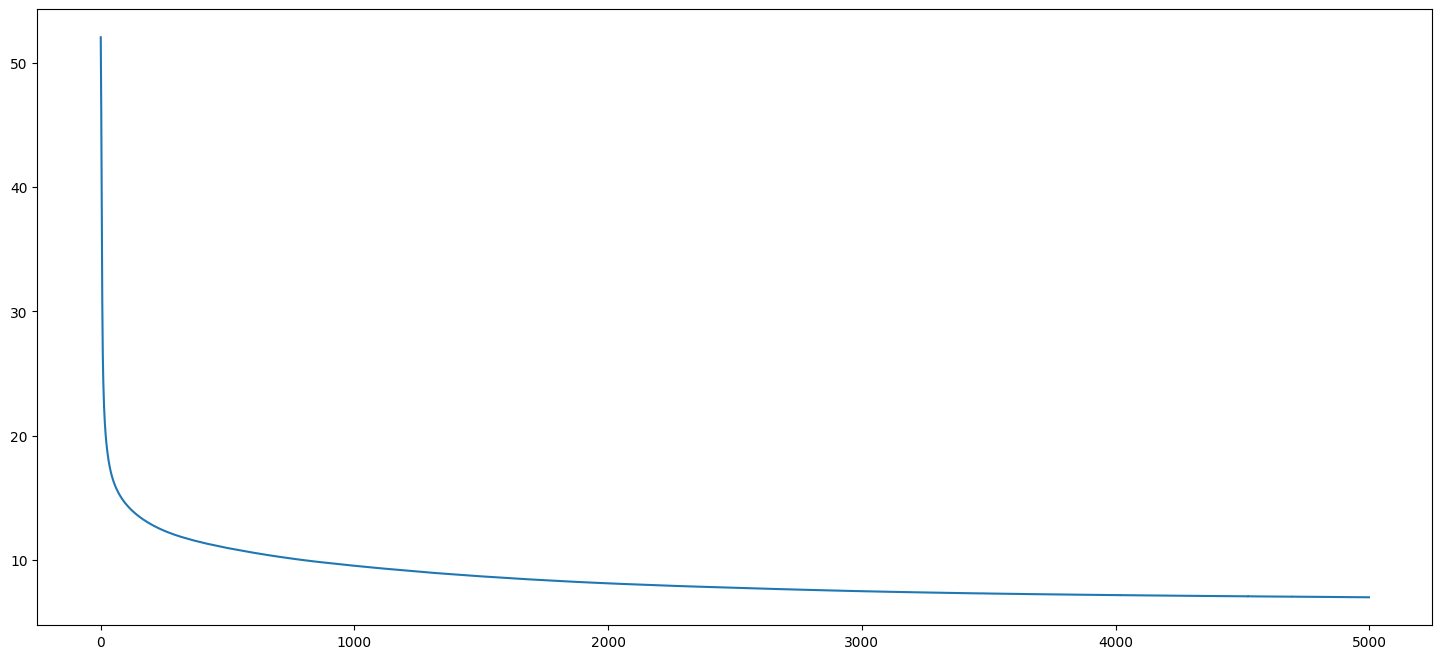

In [15]:
plt.figure(figsize=(18,8))
plt.plot(made_loss);

Podemos ver que la función de pérdida se reduce paulatinamente hasta casi converger.

Obviamente no podemos fiarnos de esto ya que siempre necesitamos una muestra de validación para asegurarnos que no nos estemos sobre especializando. Dejaremos esto como un ejercicio para el lector.

Una vez hemos entrenado el modelo podemos obtener muestras para comprobar si al menos visualmente corresponden con lo que debería.

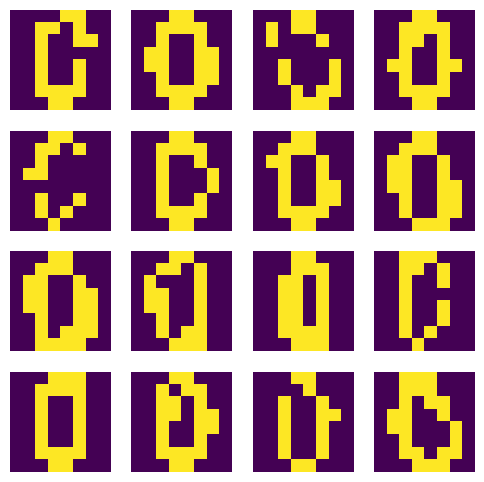

In [16]:
nim = 4

made_samp=made_model.sample(n_samples=nim*nim)

fig = plt.figure(figsize=(6,6))
for i in range(nim*nim):
    plt.subplot(nim, nim, i+1)
    plt.imshow(made_samp[i].cpu().permute(1,2,0))
    plt.axis('off')

Podemos ver que los dígitos que generamos tienen la forma adecuada.

Las muestras se han obtenido a partir del modelo autoregresivo píxel a píxel calculando su probabilidad y escogiendo un 0 o un 1 dependiendo de esta. Obviamente, repitiendo el muestreo podemos generar todos los digitos que queramos.

---
<font color="blue" size=4>
 Dado que el primer píxel es una variable independiente ¿cual os parece que es la distribución que ha aprendido en este caso?
 </font>
<br><br>
<font color="blue" size=4>
Pensadlo un momento y comentadlo entre vosotros.
 </font>

---



La gracia de tener un modelo que calcula probabilidades es obtener la probabilidad que corresponde a las muestras. El modelo es capaz de calcular los logits correspondientes a cada pixel. Aplicando la función sigmoide podemos obtener la probabilidad de que pixel tenga un valor de 1 (Bernoulli)

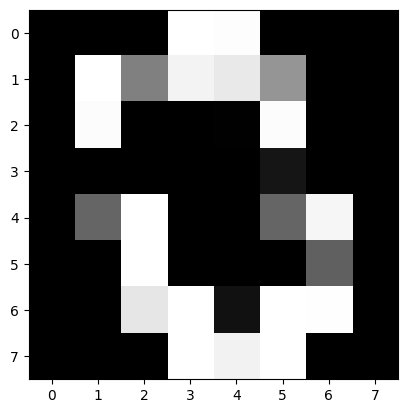

In [17]:
lg = torch.sigmoid(made_model(made_samp[2]).detach())

plt.imshow(lg.cpu().permute(1,2,0), cmap='gray');

Podemos hacerlo también para uno de los ejemplos de entrenamiento

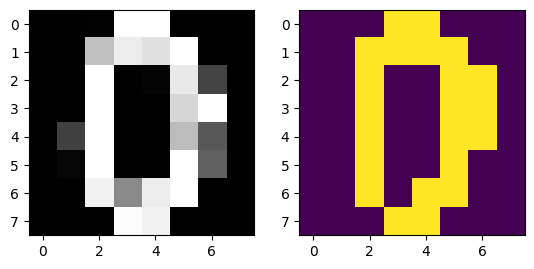

In [18]:
lg = torch.sigmoid(made_model(torch.tensor(Xb[0].reshape((-1,8,8)), dtype=torch.float32).to(device)).detach())
plt.subplot(1, 2, 1)
plt.imshow(lg.cpu().permute(1,2,0), cmap='gray');
plt.subplot(1, 2, 2)
plt.imshow(Xb[0].reshape(8,8));


---
<font color="blue" size=4>
La siguiente función calcula la log verosimilitud negativa de un conjunto de muestras
</font>
<br><br>

<font color="blue" size=4>
Intenta explicar lo que esta haciendo sabiendo que estamos modelando las variables como distribuciones de Bernoulli
</font>

---

In [19]:
def nll(model, samp):
    epsilon = 1e-15
    snll = 0.0
    for i in range(samp.shape[0]):
        mu = torch.sigmoid(model(samp[i]).detach())
        snll += ((samp[i] * torch.log(mu+epsilon)) + ((1-samp[i]) * torch.log(1-mu+epsilon))).sum()
    return -snll.cpu()

Esta es la log verosimilitud negativa de las primeras 100 muestras

In [20]:
nll(made_model, torch.tensor(Xb[:100].reshape((-1,8,8)), dtype=torch.float32).unsqueeze(1).to(device))

tensor(598.3729)

Otra ventaja de tener un modelo autoregresivo es que podemos hacer el completado de muestras parciales. Por ejemplo, podemos coger una muestra del conjunto de entrenamiento, ocultarla parcialmente y obtener el resto de la muestra condicionando el modelo a la entrada parcial.

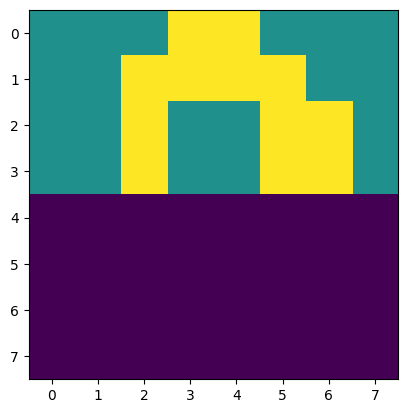

In [21]:
cond = Xb[0].copy()
cond[32:]=-1
plt.imshow(cond.reshape((8,8)));

Obviamente si hacemos el muestreo varias veces obtendremos resultados distintos. Podemos comparar tambien con el ejemplo real.

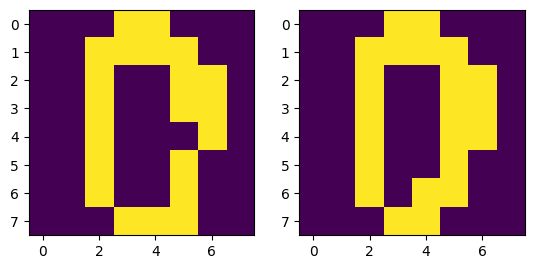

In [22]:

csamp=made_model.sample(n_samples=1,conditioned_on=torch.reshape(torch.Tensor(cond), (-1,8,8)).unsqueeze(1).to(device))
plt.subplot(1, 2, 1)
plt.imshow(csamp[0].cpu().permute(1,2,0));
plt.subplot(1, 2, 2)
plt.imshow(Xb[0].reshape(8,8));

# Pixel CNN


Pixel CNN utiliza convoluciones para definir un modelo autoregresivo que se adapta mejor a imágenes asumiendo que la influencia sobre la probabilidad de un píxel proviene de los que tiene alrededor, de manera que tenemos conexiones locales entre las variables del modelo.

Como recordaréis, estamos usando una convolucion 2D causal, por lo que estamos usando solo los píxeles que están por encima y en la misma fila a la izquierda del pixel sobre la que la estamos aplicando

![pixelcnn](https://production-media.paperswithcode.com/methods/Screen_Shot_2020-05-16_at_7.27.51_PM_tpsd8Td.png)


La red esta compuesta por una secuencia de bloques residuales (n_residual) donde cada bloque residual tiene cierto numero de canales (residual_channels), la entrada de la red esta compuesta por convoluciones 1x1 que adaptan el tamaño de la salida (head_channels)

Haremos un ajuste de este modelo con los mismos datos. Debemos ajustar los hiper párametros de la red para obtener un modelo razonable. En este caso usaremos el mismo procedimiento de entrenamiento (los hiperparámetros de la red deberían ajustarse, pero se han escogido _mágicamente_)

In [23]:
pcnn_model = models.PixelCNN(in_channels=1, out_channels=1, n_residual=2, residual_channels=6, head_channels=12)
pcnn_model.to(device)
optimizer = optim.Adam(pcnn_model.parameters(), lr=1e-3)
scheduler = lr_scheduler.MultiplicativeLR(optimizer, lr_lambda=lambda _: 0.99999)

In [24]:
pcnn_loss = train_loop(pcnn_model, optimizer, scheduler, loss_fn, bindig_dl, epochs1)

loss: 11.7879:lr: 9.5123E-04: 100%|██████████| 5000/5000 [01:56<00:00, 42.82it/s]


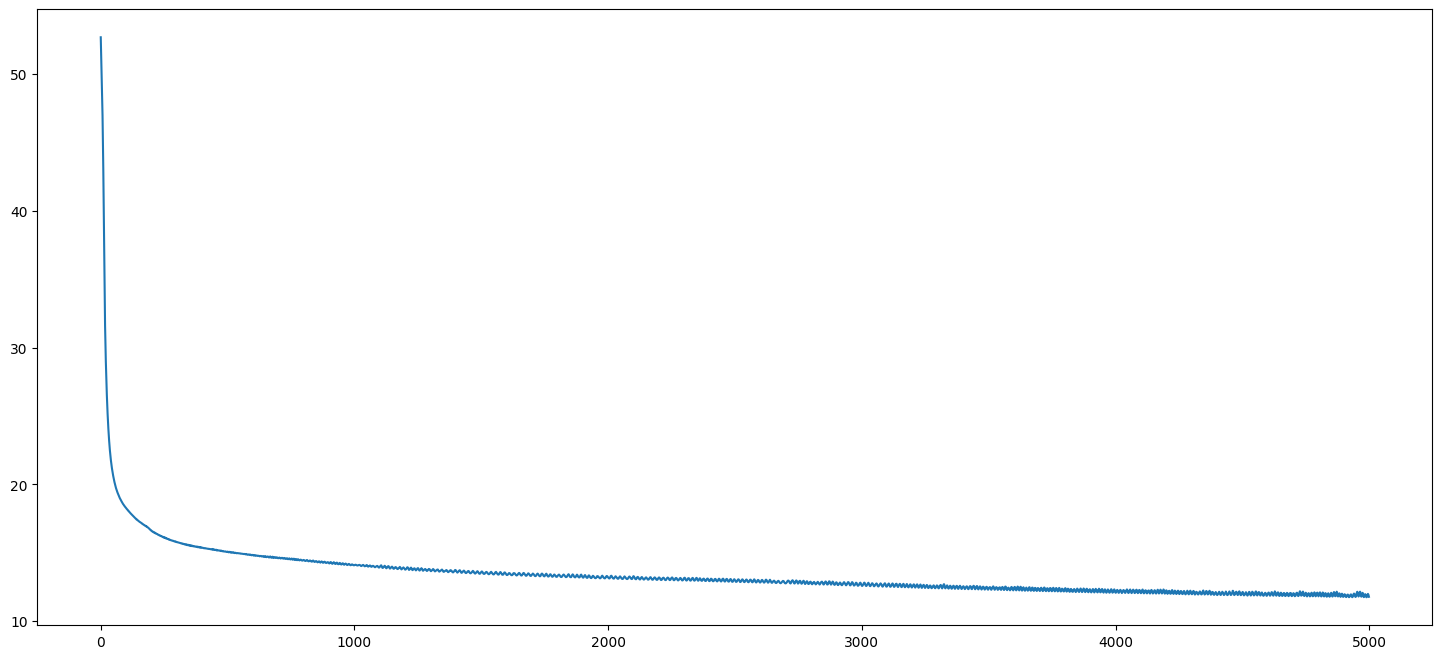

In [25]:
plt.figure(figsize=(18,8))
plt.plot(pcnn_loss);

Podemos ver las muestras que genera este modelo

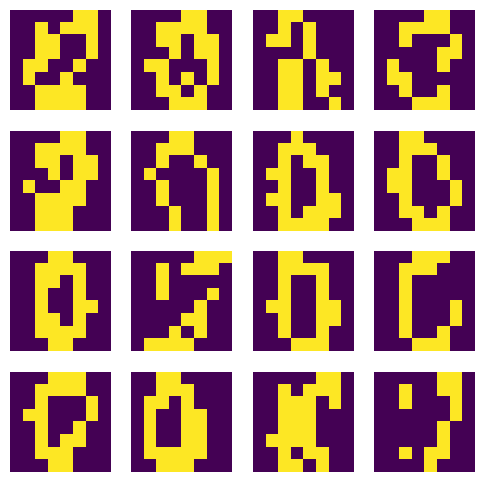

In [26]:
nim = 4
pcnn_samp=pcnn_model.sample(n_samples=nim*nim)
fig = plt.figure(figsize=(6,6))
for i in range(nim*nim):
    plt.subplot(nim, nim, i+1)
    plt.imshow(pcnn_samp[i].cpu().permute(1,2,0))
    plt.axis('off')

Podemos ahora comparar las probabilidades que asigna este modelo a los datos de entrenamiento con las que generaba MADE.

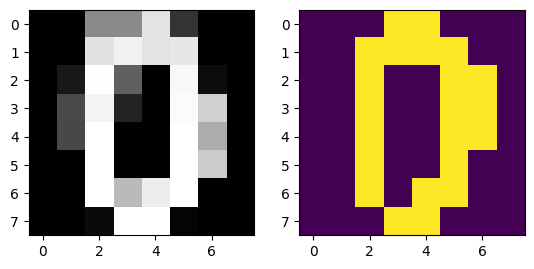

In [27]:
lg = torch.sigmoid(pcnn_model(torch.tensor(Xb[0].reshape((-1,8,8)), dtype=torch.float32).to(device)).detach())
plt.subplot(1, 2, 1)
plt.imshow(lg.cpu().permute(1,2,0), cmap='gray');
plt.subplot(1, 2, 2)
plt.imshow(Xb[0].reshape(8,8));

y la NLL de las 100 primeras muestras (deberiamos poder ajustar los hiperparametros del modelo y su capacidad para tener una NLL mas pequeña, lo dejamos como ejercicio para el lector)

In [28]:
nll(pcnn_model, torch.tensor(Xb[:100].reshape((-1,8,8)), dtype=torch.float32).unsqueeze(1).to(device))

tensor(1024.2003)

# Pixel CNN (Double down)

Modelar los datos binarios no es lo mas adecuado, pero la implementación por defecto de los modelos que tiene la librería solo permite este tipo de datos. Una alternativa sería modelar los diferentes valores de los píxeles usando canales en la imagen. Hasta ahora solo tenemos un canal, podemos generar 17 canales que correspondan con los valores correspondientes a cada pixel. Esto es parecido a lo que se hace para representar los colores en las imagenes RGB, tenemos tres colores separados que se combinan para obtener el color real.

Podemos hacer esto simplemente haciendo un one hot encoding de los valores que tiene la imagen. Este es un data loader que hace eso.

In [29]:
# Dataset para los digitos usando OneHot Encoding de sus valores (0-16)
class Digits(Dataset):
    def __init__(self, data):
        self.data = torch.reshape(torch.Tensor(data), (-1,8,8))

    def __getitem__(self, index):
        x = self.data[index]

        return F.one_hot(x.long(), num_classes=17).to(torch.float32).permute(2,0,1)

    def __len__(self):
        return len(self.data)

digdata = Digits(X)
digits_dl = torch.utils.data.DataLoader(digdata, batch_size=64)

---


<font color="blue" size=4>
Esta parece una manera sencilla de transformar un problema que no es binario a uno binario, pero realmente estaremos aprendiendo una distribución de probabilidad que será más compleja de lo necesario.
 </font>

 - ¿Qué diferencia hay entre la distribucion autoregresiva que modela la red y las dependencias que hay realmente entre los valores de los píxeles?

 - ¿Recordáis cómo se modela la salida multinomial en PixelCNN? ¿Qué ventaja/diferencia tiene respecto a hacerlo así?

 - ¿Recordáis cómo se modela en PixelCNN++?

---

Podemos ver que ahora un ejemplo es un tensor 17 * 8 * 8

In [30]:
digdata[0].shape

torch.Size([17, 8, 8])

Ahora necesitaremos una red con algo más de capacidad, además deberíamos hacer una exploración para ajustar sus hiperparámetros (ahora estan ajustados mágicamente &#x1F609;).

Estamos también multiplicando el tamaño de los datos por 17 y aunque la capacidad de proceso de la GPU sera suficiente en este caso (tenemos pocos datos) podéis ver que no es una estrategia escalable.

In [31]:
pcnn2_model = models.PixelCNN(in_channels=17, out_channels=17, n_residual=8, residual_channels=24, head_channels=16)
pcnn2_model.to(device)
optimizer = optim.Adam(pcnn2_model.parameters(), lr=1e-4)
scheduler = lr_scheduler.MultiplicativeLR(optimizer, lr_lambda=lambda _: 0.9999)

In [32]:
pcnn2_loss = train_loop(pcnn2_model, optimizer, scheduler, loss_fn, digits_dl, epochs1)

loss: 20.4003:lr: 6.0652E-05: 100%|██████████| 5000/5000 [02:50<00:00, 29.26it/s]


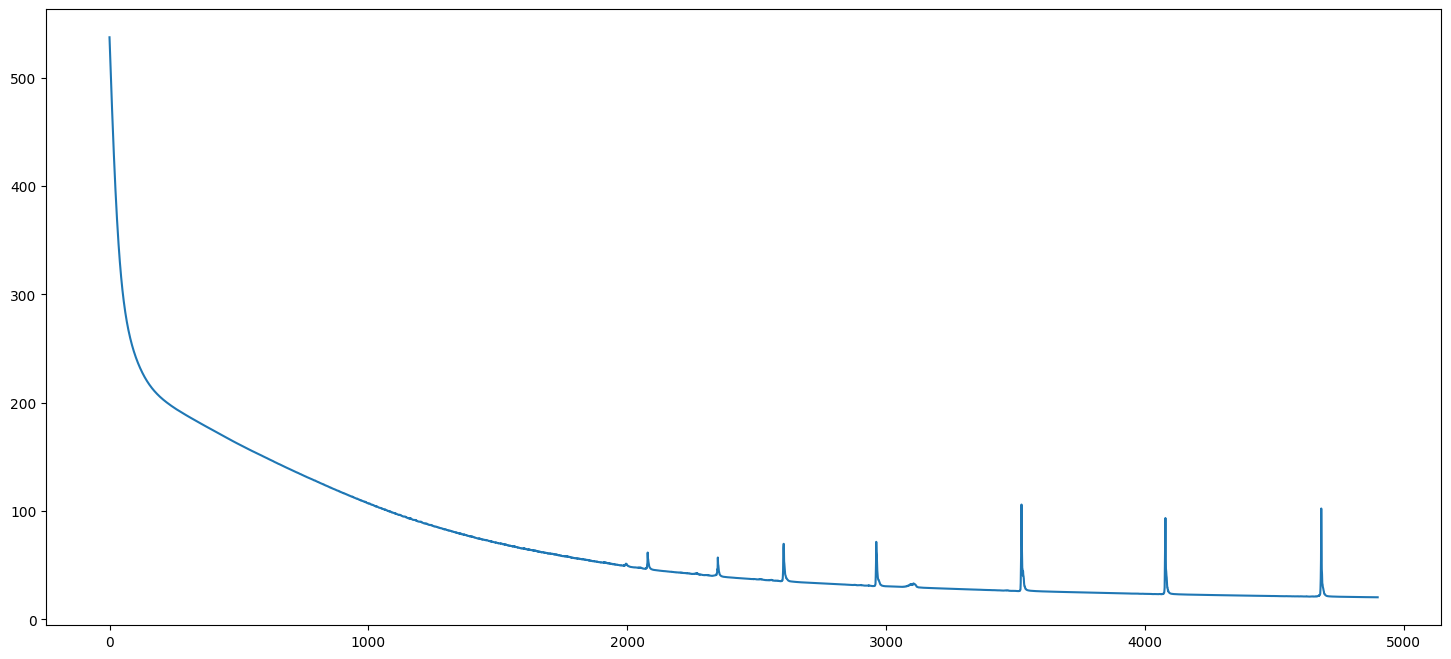

In [33]:
plt.figure(figsize=(18,8))
plt.plot(pcnn2_loss[100:]);

Si generamos muestras con el modelo aprendido, no son maravillosas, pero algunas tienen cierto parecido en forma a lo que queremos aprender. Probablemente la intensidad de los pixels no sea demasiado buena.

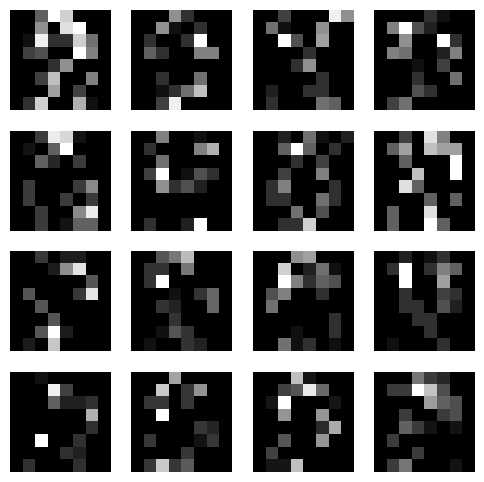

In [34]:
nim = 4
pcnn_samp=pcnn2_model.sample(n_samples=nim*nim)
fig = plt.figure(figsize=(6,6))
for i in range(nim*nim):
    plt.subplot(nim, nim, i+1)
    plt.imshow(np.argmax(pcnn_samp[i].cpu().numpy(), axis=0),cmap='gray')
    plt.axis('off')

---
  <font color="blue" size=4>
Fijaos en qué se esta haciendo para representar los valores de los píxeles de los dígitos</font>

 -  ¿Qué valor tenemos para la intensidad de cada píxel?
 - ¿Qué problema nos encontraremos con los valores que corresponden a un píxel? ¿cómo deberíamos  obtener el valor de mayor intensidad del píxel ?

---


# Gated Pixel CNN

El problema de pixel CNN era que acababamos perdiendo información por la forma en la que se hacia la convolución causal. La mejora consiste en tener dos convoluciones, una 2D que se encargue de los píxeles de las filas anteriores y una convolucion causal 1D que se encargue de los píxeles anteriores en la fila.

![gated pixelcnn](http://sergeiturukin.com/assets/2017-02-23-133739_307x163_scrot.png)

Ahora la red es más compleja, tenemos dos ramas paralelas, una por cada tipo de convolución que se combinan para la predicción en las que aplicamos puertas mediante las funciones sigmoide y tanh para modular la importancia de la información de los canales.

![gated pixelcnn arch](http://sergeiturukin.com/assets/2017-02-23-135658_1055x427_scrot.png)

Los parametros que tenemos en la implementación de la libreria son parecidos, tenemos un numero de bloques (n_gated) con cierto numero de canales dentro del bloque (gated_channels) y un numero de canales para las convoluciones 1x1 que generan la salida.

Deberíamos ajustar los hiperparámetros que han sido puestos también mágicamente.

In [35]:
gpcnn_model = models.GatedPixelCNN(in_channels=1, out_channels=1, n_gated=4, gated_channels=8, head_channels=8)
gpcnn_model.to(device)
optimizer = optim.Adam(gpcnn_model.parameters(), lr=1e-3)
scheduler = lr_scheduler.MultiplicativeLR(optimizer, lr_lambda=lambda _: 0.99999)

In [36]:
gpcnn_loss = train_loop(gpcnn_model, optimizer, scheduler, loss_fn, bindig_dl, epochs2)

loss: 7.6884:lr: 9.8020E-04: 100%|██████████| 2000/2000 [02:20<00:00, 14.19it/s]


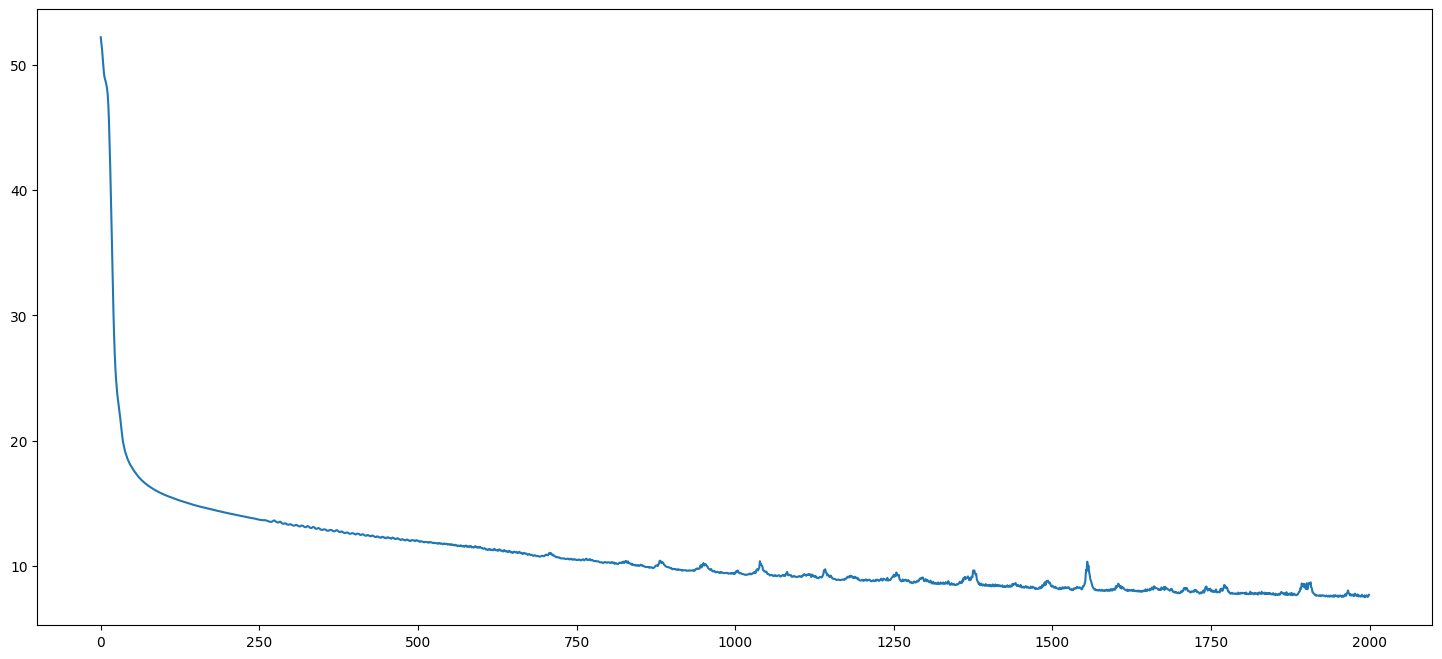

In [37]:
plt.figure(figsize=(18,8))
plt.plot(gpcnn_loss);

La calidad de las muestras dependera del tiempo de entrenamiento y el tamaño de la red, obviamente

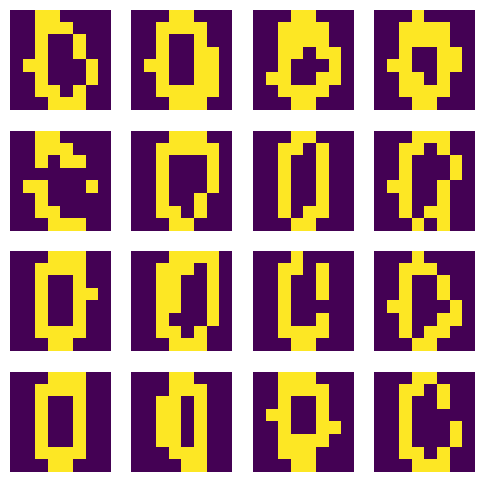

In [38]:
nim = 4
gpcnn_samp=gpcnn_model.sample(n_samples=nim*nim)
fig = plt.figure(figsize=(6,6))
for i in range(nim*nim):
    plt.subplot(nim, nim, i+1)
    plt.imshow(gpcnn_samp[i].cpu().permute(1,2,0))
    plt.axis('off')

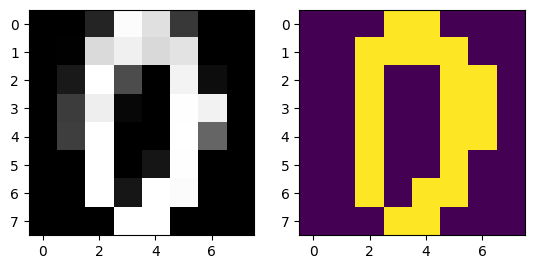

In [39]:
lg = torch.sigmoid(gpcnn_model(torch.tensor(Xb[0].reshape((-1,8,8)), dtype=torch.float32).unsqueeze(1).to(device)).detach())

plt.subplot(1, 2, 1)
plt.imshow(lg.squeeze(1).cpu().permute(1,2,0),cmap='gray');
plt.subplot(1, 2, 2)
plt.imshow(Xb[0].reshape(8,8));

In [40]:
def nll2(model, samp):
    epsilon =1e-15
    snll = 0.0
    for i in range(samp.shape[0]):
        mu = torch.sigmoid(model(samp[i].unsqueeze(1)).detach())
        snll += ((samp[i] * torch.log(mu+epsilon)) + ((1-samp[i]) * torch.log(1-mu+epsilon))).sum()
    return -snll.cpu()

nll2(gpcnn_model, torch.tensor(Xb[:100].reshape((-1,8,8)), dtype=torch.float32).unsqueeze(1).to(device))

tensor(646.8301)

La NLL no parece tan buena, es posible que la red necesite una exploracion mas exhaustiva de hiperparametros y algo más de paciencia (probablemente aumentando el parametro `n_gates` a 6 :-)

# Image GPT

Image GPT utiliza la arquitectura transformer como modelo autoregresivo, esta trabaja con un embedding de la imagen y predice el siguiente token  dada una secuencia de tokens. La arquitectura tiene solo el decoder de la arquitectura transformer.

Esta implementacion trabaja a nivel de pixel. La entrada es transformada a una secuencia que es pasada por diferentes capas transformer hasta generar el siguiente pixel.

La arquitectura define el numero de bloques transformer (n_transformer_blocks), el numero de cabezas del transformer (n_attention_heads, ha de ser un divisor del tamaño de la entrada) y el numero de canales que se usan en el embedding del transformer (n_embedding_channels).

Los parámetros por supuesto se han decidido también mágicamente.

In [41]:
igpt_model = models.ImageGPT(in_channels=1, out_channels=1, in_size=8,
        n_transformer_blocks=3,
        n_attention_heads=8,
        n_embedding_channels=8)
igpt_model.to(device)
optimizer = optim.Adam(igpt_model.parameters(), lr=5e-3)
scheduler = lr_scheduler.MultiplicativeLR(optimizer, lr_lambda=lambda _: 0.999)

In [42]:
igpt_loss = train_loop(igpt_model, optimizer, scheduler, loss_fn, bindig_dl, epochs2)

loss: 6.6037:lr: 6.7600E-04: 100%|██████████| 2000/2000 [02:05<00:00, 15.89it/s]


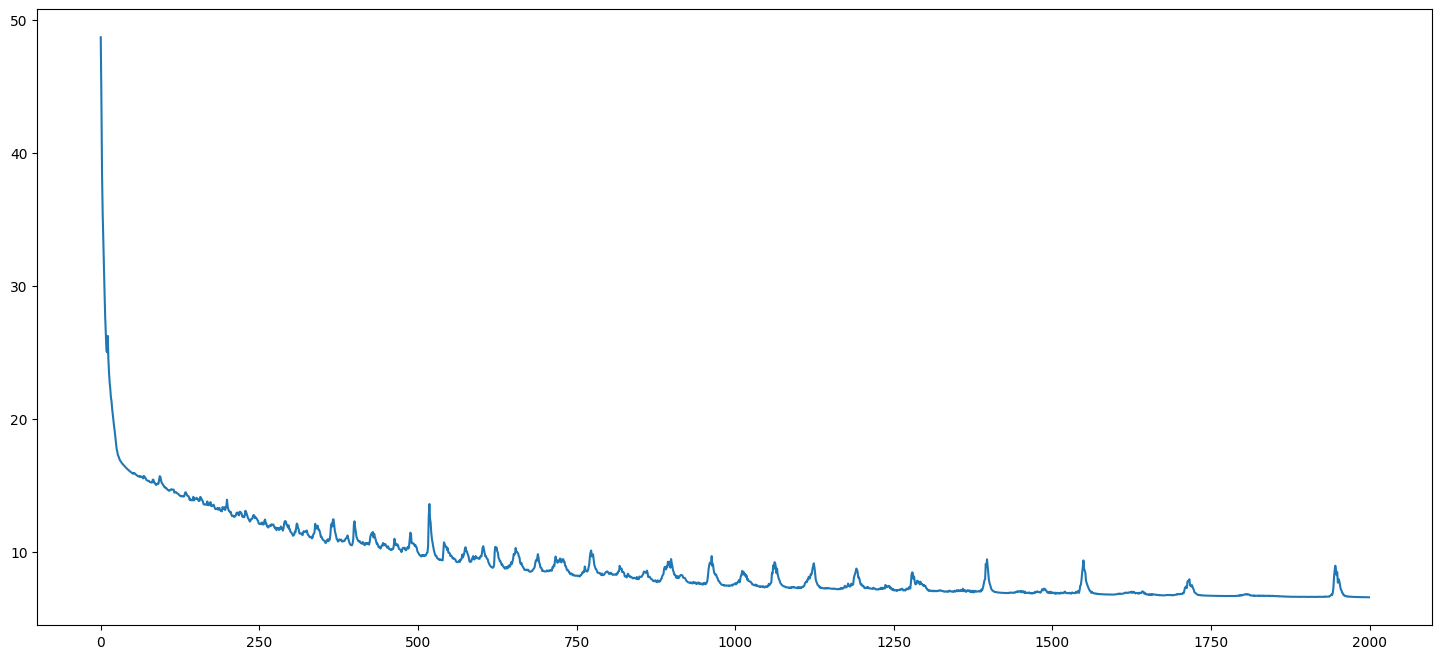

In [43]:
plt.figure(figsize=(18,8))
plt.plot(igpt_loss);

Las muestras parecen algo mejores (?)

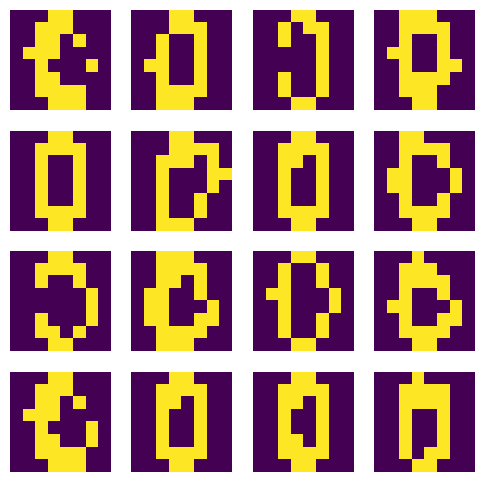

In [44]:
nim = 4
pcnn_samp=igpt_model.sample(n_samples=nim*nim)
fig = plt.figure(figsize=(6,6))
for i in range(nim*nim):
    plt.subplot(nim, nim, i+1)
    plt.imshow(pcnn_samp[i].cpu().permute(1,2,0))
    plt.axis('off')

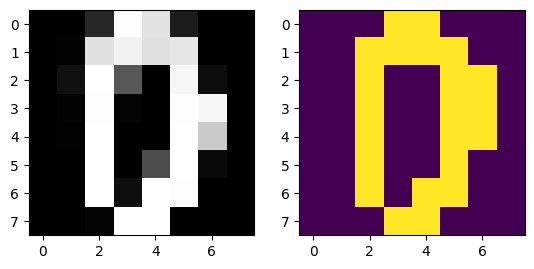

In [45]:
lg = torch.sigmoid(igpt_model(torch.tensor(Xb[0].reshape((-1,8,8)), dtype=torch.float32).unsqueeze(1).to(device)).detach())

plt.subplot(1, 2, 1)
plt.imshow(lg.squeeze(1).cpu().permute(1,2,0),cmap='gray');
plt.subplot(1, 2, 2)
plt.imshow(Xb[0].reshape(8,8));

La NLL es mejor, requeriria una exploración de hiperparametros y un modelo de mas capacidad o quizar menos, una muestra de validación nos permitiria ver si se ha sobre especializado, otra vez ejercicio para el lector

In [46]:
nll2(igpt_model, torch.tensor(Xb[:100].reshape((-1,8,8)), dtype=torch.float32).unsqueeze(1).to(device))

tensor(560.1668)

# Image GPT (Double down again)

Visto que este modelo puede obtener mejores resultados podemos comprobar si podemos generar los valores de los píxeles con esta arquitectura

In [47]:
# Es la misma que antes, pero con un cambio para cuadrar con la implementacion de image GPT de la libreria
def loss_fn2(x, preds):
    batch_size = x.shape[0]
    x, preds = x.reshape((batch_size, -1)), preds.reshape((batch_size, -1))
    loss = F.binary_cross_entropy_with_logits(preds, x, reduction="none")
    return loss.sum(dim=1).mean()

In [48]:
igpt2_model = models.ImageGPT(in_channels=17, out_channels=17, in_size=8,
        n_transformer_blocks=6,
        n_attention_heads=8,
        n_embedding_channels=16)
igpt2_model.to(device)
optimizer = optim.Adam(igpt2_model.parameters(), lr=1e-3)
scheduler = lr_scheduler.MultiplicativeLR(optimizer, lr_lambda=lambda _: 0.9999)

In [49]:
igpt2_loss = train_loop(igpt2_model, optimizer, scheduler, loss_fn2, digits_dl, 3000)

loss: 16.3949:lr: 7.4081E-04: 100%|██████████| 3000/3000 [03:16<00:00, 15.24it/s]


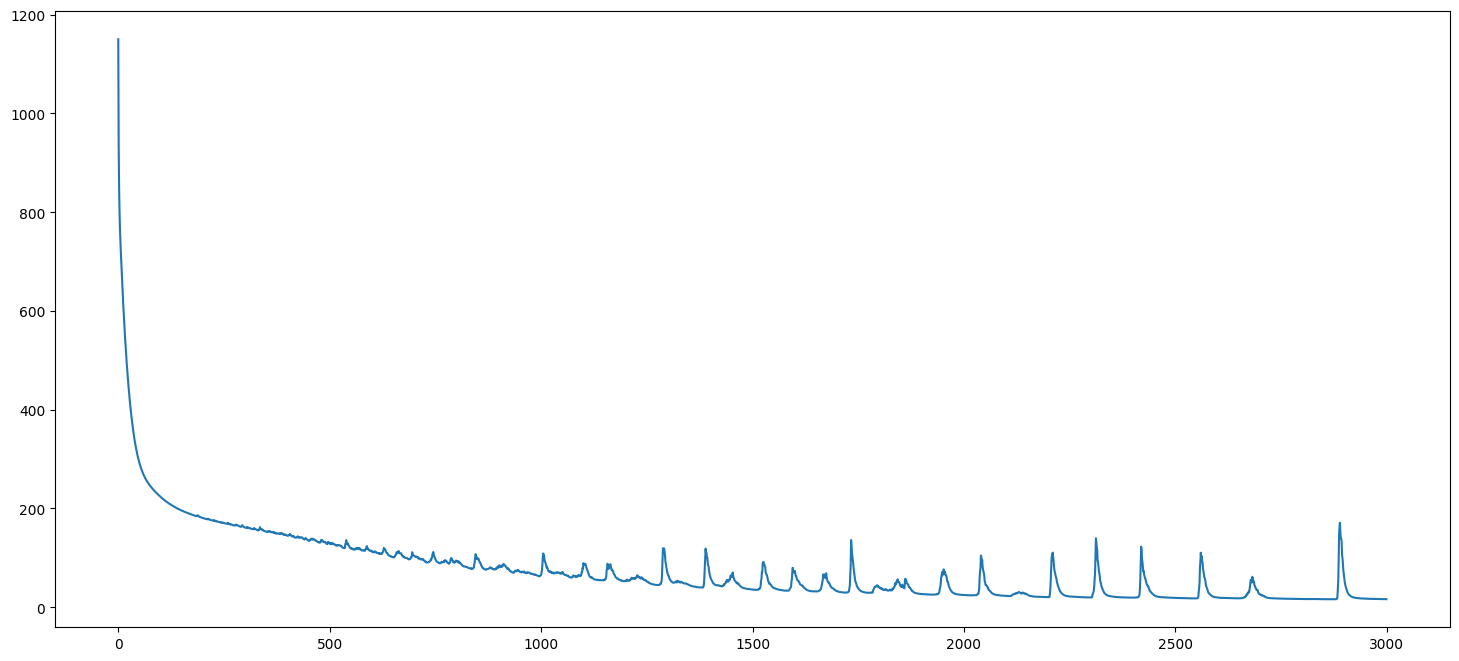

In [50]:
plt.figure(figsize=(18,8))
plt.plot(igpt2_loss);

y ahora las muestras deberían ser bastante más reconocibles que las generadas por pixelCNN

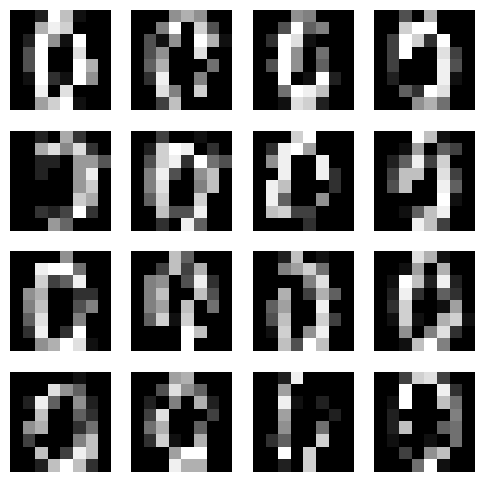

In [51]:
nim = 4
igpt2_samp=igpt2_model.sample(n_samples=nim*nim)
fig = plt.figure(figsize=(6,6))
for i in range(nim*nim):
    plt.subplot(nim, nim, i+1)
    plt.imshow(np.argmax(igpt2_samp[i].cpu().numpy(), axis=0), cmap='gray')
    plt.axis('off')

In [52]:
print(f"Total Running time {timedelta(seconds=(time() - init_time))}")

Total Running time 0:13:58.898525


---


<font color="red" size=6>
Ejercicio de laboratorio entregable
</font>


Este laboratorio tiene un ejercicio entregable. Teneis el enunciado en la pagina web del curso donde estaba este notebook.

---

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [54]:
!pip install apafib
from apafib import load_MITBIH

df = load_MITBIH()
df.head()


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for apafib: filename=apafib-0.3.0-py3-none-any.whl size=21323 sha256=5df6500b347f2642714daa9c87e06fe21f40e63aabce768ec8765670f7d2283d
  Stored in directory: /root/.cache/pip/wheels/d4/28/10/7c3ef346cdaffcde387e7e80c2e17d1905a744a00e5d53c9d8
Successfully built apafib


,0,1,2,3,4,5,6,7,8,9,...,85,86,87,88,89,90,91,92,93,target
0,0.988684,0.225644,0.005137,0.067679,0.045216,0.052735,0.078290,0.078020,0.106516,0.131787,...,-0.000027,0.000037,-0.000035,0.000024,-0.000009,-0.000004,0.000013,-0.000017,1.493154e-05,Normal
1,0.988463,0.255621,0.014753,0.135870,0.149761,0.145114,0.260982,0.331085,0.323523,0.311399,...,-0.000062,0.000172,-0.000210,0.000184,-0.000115,0.000032,0.000040,-0.000084,9.528151e-05,ArrS
2,0.975710,0.541291,0.056431,0.001236,0.046895,0.023730,0.047825,0.033864,0.042665,0.038015,...,-0.000408,-0.000067,0.000417,-0.000612,0.000628,-0.000479,0.000233,0.000025,-2.191219e-04,ArrS
3,0.988539,0.640719,0.211277,0.153709,0.143665,0.113944,0.136569,0.111482,0.123713,0.099498,...,-0.000011,0.000007,-0.000002,-0.000002,0.000005,-0.000006,0.000005,-0.000003,5.437810e-07,Normal
4,0.718637,0.413863,0.123311,0.058860,0.055222,0.043426,0.060662,0.056730,0.079994,0.107037,...,0.000003,-0.000017,0.000023,-0.000021,0.000015,-0.000006,-0.000003,0.000008,-1.048218e-05,Normal


In [55]:
df_normal = df[df["target"] == "Normal"].copy()
df_normal = df_normal.drop(columns=["target"])

# Añadimos 2 columnas adicionales
df_normal["pad1"] = 0
df_normal["pad2"] = 0

signals = df_normal.values   # numpy array (N, 96)
signals.shape


(7263, 96)

In [56]:
def segment_signal(sig, window):
    return np.split(sig, len(sig)//window)


In [121]:
window_sizes = [4, 6, 8, 12]
vocab_sizes  = [128, 256, 512]

quantizers = {}

for w in window_sizes:
    for v in vocab_sizes:
        print(f"Entrenando GMM para window={w}, vocab={v}...")

        all_windows = []
        for sig in signals:
            parts = segment_signal(sig, w)
            all_windows.extend(parts)

        all_windows = np.array(all_windows)

        gmm = GaussianMixture(n_components=v, covariance_type="full", random_state=0)
        gmm.fit(all_windows)

        quantizers[(w, v)] = gmm

print("Cuantización completada.")


Entrenando GMM para window=4, vocab=128...
Entrenando GMM para window=4, vocab=256...
Entrenando GMM para window=4, vocab=512...
Entrenando GMM para window=6, vocab=128...
Entrenando GMM para window=6, vocab=256...
Entrenando GMM para window=6, vocab=512...
Entrenando GMM para window=8, vocab=128...
Entrenando GMM para window=8, vocab=256...
Entrenando GMM para window=8, vocab=512...
Entrenando GMM para window=12, vocab=128...
Entrenando GMM para window=12, vocab=256...
Entrenando GMM para window=12, vocab=512...
Cuantización completada.


In [122]:
def discretize_signal(sig, gmm, window):
    parts = segment_signal(sig, window)
    parts = np.array(parts)
    labels = gmm.predict(parts)
    return labels


In [123]:
datasets = {}

for w in window_sizes:
    for v in vocab_sizes:
        gmm = quantizers[(w, v)]
        seqs = []
        for sig in signals:
            seq = discretize_signal(sig, gmm, w)
            seqs.append(seq)
        datasets[(w, v)] = np.array(seqs)


In [124]:
splits = {}

for key, data in datasets.items():
    train, temp = train_test_split(data, test_size=0.5, random_state=0)
    val, test = train_test_split(temp, test_size=0.5, random_state=0)
    splits[key] = (train, val, test)

splits[(8,128)][0].shape


(3631, 12)

In [181]:
# ============================================================
#        SELECCIÓN DE COMBINACIÓN window / vocab
# ============================================================

window = 8
vocab  = 256         # <-- CAMBIAR AQUÍ A MANO (8/128, 8/256, 12/128, 12/256)

# Cargar splits correspondientes
train, val, test = splits[(window, vocab)]

# ============================================================
#                ONE HOT ENCODING
# ============================================================

def one_hot_encode(seqs, vocab):
    N, L = seqs.shape
    out = np.zeros((N, L, vocab))
    out[np.arange(N)[:,None], np.arange(L)[None,:], seqs] = 1
    return out

train_oh = one_hot_encode(train, vocab)
val_oh   = one_hot_encode(val, vocab)

# ============================================================
#                   MADE CORREGIDO
# ============================================================

class MADE(nn.Module):
    def __init__(self, input_dim, hidden_dim, vocab):
        super().__init__()
        self.vocab = vocab
        self.input_dim = input_dim  # T

        self.fc1 = nn.Linear(input_dim * vocab, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, input_dim * vocab)

    def forward(self, x):
        batch_size = x.size(0)
        x_flat = x.view(batch_size, -1)
        h = F.relu(self.fc1(x_flat))
        out = self.fc2(h)
        return out.view(batch_size, self.input_dim, self.vocab)


# ============================================================
#                         LOSS
# ============================================================

def loss_fn(logits, targets):
    logits = logits.reshape(-1, logits.size(-1))
    targets = targets.argmax(dim=-1).reshape(-1)
    return F.cross_entropy(logits, targets)


# ============================================================
#                    TRAIN LOOP
# ============================================================

def train_made(model, train_loader, val_loader, epochs=20, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    for ep in range(epochs):
        model.train()
        ep_loss = 0

        for batch in train_loader:
            batch = batch.to(device)
            logits = model(batch)
            loss = loss_fn(logits, batch)

            opt.zero_grad()
            loss.backward()
            opt.step()

            ep_loss += loss.item()

        train_losses.append(ep_loss / len(train_loader))

        # VALIDACIÓN
        model.eval()
        with torch.no_grad():
            vloss = 0
            for batch in val_loader:
                batch = batch.to(device)
                logits = model(batch)
                vloss += loss_fn(logits, batch).item()

            val_losses.append(vloss / len(val_loader))

        print(f"Epoch {ep}: train={train_losses[-1]:.4f}, val={val_losses[-1]:.4f}")

    return train_losses, val_losses


# ============================================================
#                     DATALOADERS
# ============================================================

import torch.utils.data as data

train_tensor = torch.tensor(train_oh, dtype=torch.float32)
val_tensor   = torch.tensor(val_oh, dtype=torch.float32)

train_loader = data.DataLoader(train_tensor, batch_size=64, shuffle=True)
val_loader   = data.DataLoader(val_tensor, batch_size=64, shuffle=False)

# ============================================================
#                     ENTRENAMIENTO
# ============================================================

model = MADE(
    input_dim=train_oh.shape[1],    # T
    hidden_dim=256,
    vocab=vocab
).to(device)

train_losses, val_losses = train_made(model, train_loader, val_loader, epochs=60)


Epoch 0: train=3.8726, val=2.6472
Epoch 1: train=2.3131, val=2.0254
Epoch 2: train=1.7095, val=1.5612
Epoch 3: train=1.2999, val=1.2662
Epoch 4: train=1.0222, val=1.0642
Epoch 5: train=0.8115, val=0.9142
Epoch 6: train=0.6461, val=0.7959
Epoch 7: train=0.5122, val=0.7013
Epoch 8: train=0.4026, val=0.6294
Epoch 9: train=0.3147, val=0.5693
Epoch 10: train=0.2431, val=0.5213
Epoch 11: train=0.1880, val=0.4823
Epoch 12: train=0.1451, val=0.4522
Epoch 13: train=0.1122, val=0.4277
Epoch 14: train=0.0877, val=0.4078
Epoch 15: train=0.0696, val=0.3923
Epoch 16: train=0.0558, val=0.3797
Epoch 17: train=0.0456, val=0.3683
Epoch 18: train=0.0377, val=0.3607
Epoch 19: train=0.0317, val=0.3528
Epoch 20: train=0.0270, val=0.3481
Epoch 21: train=0.0233, val=0.3421
Epoch 22: train=0.0203, val=0.3376
Epoch 23: train=0.0179, val=0.3342
Epoch 24: train=0.0158, val=0.3307
Epoch 25: train=0.0141, val=0.3282
Epoch 26: train=0.0126, val=0.3255
Epoch 27: train=0.0114, val=0.3229
Epoch 28: train=0.0104, val=0.

In [182]:
def sample(model, L, vocab):
    model.eval()
    seq = np.zeros(L, dtype=int)
    with torch.no_grad():
        for i in range(L):
            inp = torch.zeros((1, L, vocab)).to(device)
            for j in range(i):
                inp[0,j,seq[j]] = 1
            logits = model(inp)
            probs = F.softmax(logits[0,i], dim=0).cpu().numpy()
            seq[i] = np.random.choice(np.arange(vocab), p=probs)
    return seq


In [183]:
def reconstruct(seq, gmm, window):
    centroids = gmm.means_
    parts = [centroids[s] for s in seq]
    return np.concatenate(parts)


In [184]:
def log_likelihood(model, seq_oh):
    with torch.no_grad():
        logits = model(torch.tensor(seq_oh, dtype=torch.float32).unsqueeze(0).to(device))
        logits = logits.squeeze(0)
        probs = F.softmax(logits, dim=1)
        ll = torch.sum(torch.log(torch.sum(probs * torch.tensor(seq_oh).to(device), dim=1)))
    return ll.item()


In [185]:
test_oh = one_hot_encode(test, vocab)

lls = [log_likelihood(model, x) for x in test_oh]
print("Media verosimilitud test:", np.mean(lls))


Media verosimilitud test: -3.5963185220320164


In [186]:
df_other = df[df["target"] != "Normal"].drop(columns=["target"])
df_other["pad1"] = 0
df_other["pad2"] = 0

other_sigs = df_other.values

seqs_other = [discretize_signal(sig, quantizers[(window,vocab)], window) for sig in other_sigs]
seqs_other_oh = one_hot_encode(np.array(seqs_other), vocab)

ll_other = [log_likelihood(model, s) for s in seqs_other_oh]
print("Verosimilitud media otras clases:", np.mean(ll_other))


Verosimilitud media otras clases: -17.742729292949978


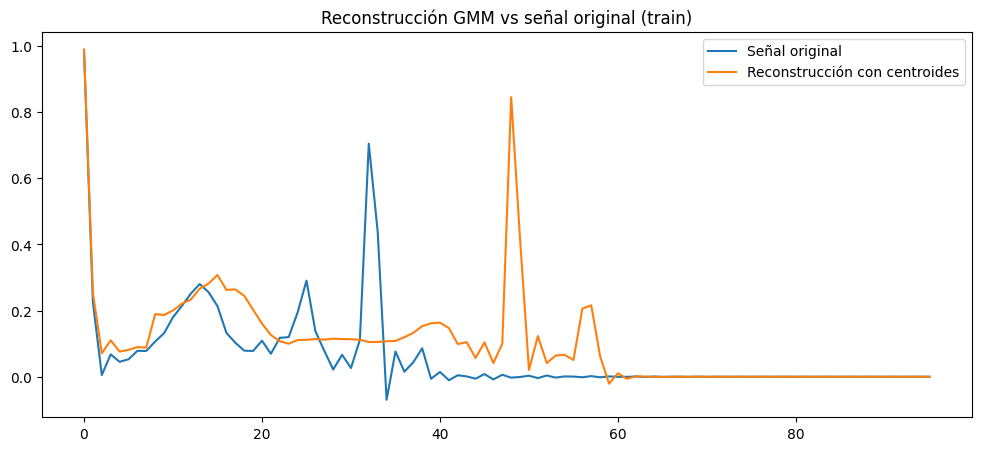

In [187]:
# Elegimos una señal del train
idx = 0
sig = train[idx]                      # secuencia discreta del vocabulario
reconstructed = reconstruct(sig, quantizers[(window,vocab)], window)

# Versión continua original
original = signals[idx]               # esta es la señal normal continua de 96 puntos

plt.figure(figsize=(12,5))
plt.plot(original, label="Señal original")
plt.plot(reconstructed, label="Reconstrucción con centroides")
plt.title("Reconstrucción GMM vs señal original (train)")
plt.legend()
plt.show()


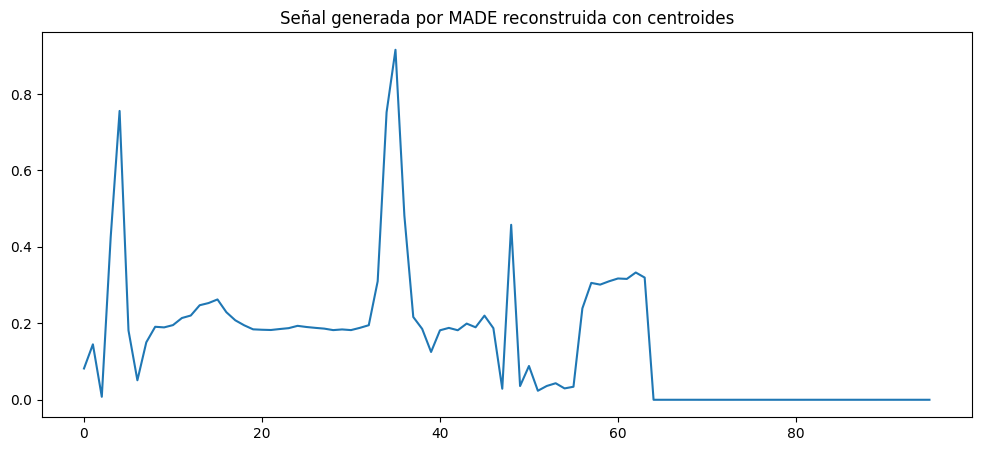

In [193]:
# Longitud de secuencia (T)
L = train.shape[1]

# Generamos una secuencia nueva discreta
gen_seq = sample(model, L, vocab)

# Reconstrucción continua
gen_reconstructed = reconstruct(gen_seq, quantizers[(window,vocab)], window)

plt.figure(figsize=(12,5))
plt.plot(gen_reconstructed)
plt.title("Señal generada por MADE reconstruida con centroides")
plt.show()
